In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str #사용자 질문문
    answer: str #세율
    tax_base_equation: str #과세표준 계산 수식
    tax_deduction: str #공제액
    market_ratio: str #공정시장가액비율
    tax_base: str #과세표준 계산   

graph_builder = StateGraph(AgentState)

In [3]:
%pip install -qU pypdf langchain-community langchain-text-splitters

Note: you may need to restart the kernel to use updated packages.


In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1500,
    chunk_overlap = 100,
    separators=['\n\n', '\n']
)

In [5]:
# from langchain_community.document_loaders import TextLoader

# text_path = './documents/real_estate_tax.txt'

# loader = TextLoader(text_path, encoding='utf-8')
# document_list = loader.load_and_split(text_splitter)

In [6]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma

embeddings = OpenAIEmbeddings(model='text-embedding-3-large')

# vector_store = Chroma.from_documents(
#     documents=document_list,
#     embedding=embeddings,
#     collection_name = 'real_estate_tax',
#     persist_directory = './real_estate_tax_collection'
# )

vector_store = Chroma(
        collection_name="real_estate_tax",
        persist_directory="./real_estate_tax_collection",
        embedding_function=embeddings
    )

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [7]:
query = "일반인이 5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내야 하나요?"

In [8]:
from langchain_openai import ChatOpenAI
from langsmith import Client
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate

client = Client()
rag_prompt = client.pull_prompt("rlm/rag-prompt")

llm = ChatOpenAI(model='gpt-5.4')
small_llm = ChatOpenAI(model='gpt-5.4-mini')

In [9]:
tax_base_retrieval_chain = (
    {'context': retriever, 'question': RunnablePassthrough()} 
    | rag_prompt 
    | llm 
    | StrOutputParser()
)

tax_base_equation_prompt = ChatPromptTemplate.from_messages([
    ('system', '사용자의 질문에서 과세표준을 계산하는 방법을 수식으로 나타내주세요. 과세표준 수식만 리턴해주세요'),
    ('human', '{tax_base_equation_information}')
])

tax_base_equation_chain = (
    {'tax_base_equation_information': RunnablePassthrough()}
    | tax_base_equation_prompt
    | llm
    | StrOutputParser()
)

tax_base_chain = {'tax_base_equation_information' : tax_base_retrieval_chain} | tax_base_equation_chain

def get_tax_base_equation(state: AgentState):
    tax_base_equation_question = '주택에 대한 종합부동산세 계산시 과세표준을 계산하는 방법을 수식으로 표현해서 알려주세요'
    
    tax_base_equation = tax_base_chain.invoke(tax_base_equation_question)
    
    return {'tax_base_equation': tax_base_equation}


In [10]:
get_tax_base_equation({})


{'tax_base_equation': '과세표준 = max(0, (주택 공시가격 합산액 − 공제금액) × 공정시장가액비율)'}

In [11]:
tax_deduction_chain = (
    {'context': retriever, 'question': RunnablePassthrough()}
    | rag_prompt 
    | llm 
    | StrOutputParser()
)

def get_tax_deduction(state: AgentState):
    tax_deduction_question = '주택에 대한 종합부동산세 계산시 사용하는 공제금액을 알려주세요'
    tax_deduction = tax_deduction_chain.invoke(tax_deduction_question)
    return {'tax_deduction': tax_deduction}

In [12]:
get_tax_deduction({})

{'tax_deduction': '주택에 대한 종합부동산세 계산 시 공제금액은 **1세대 1주택자 12억 원**, **법인 또는 법인으로 보는 단체 6억 원**, **그 밖의 자 9억 원**입니다.  \n즉, 주택 공시가격 합계에서 해당 공제금액을 뺀 뒤 과세표준을 계산합니다.'}

In [13]:
from langchain_tavily import TavilySearch
from datetime import date

tavily_search_tool = TavilySearch(
    max_results=3,
    topic="general",
    include_answer=True,
    include_raw_content=True,
    include_images=True,
    search_depth="advanced",    
)

tax_market_ratio_prompt = ChatPromptTemplate.from_messages([
('system', f'아래 정보를 기반으로 해당하는 공정시장 가액비율을 계산해 주세요\n\nContext:\n{{context}}'),
('human', '{query}')
])

def get_market_ratio(state: AgentState):
    query = f"오늘 날짜:({date.today()})의 주택에 대한 종합부동산세 계산시 공정시장가액비율은 몇 %인가요?"
    context = tavily_search_tool.invoke(query)
    print(f'context = {context}')
    tax_market_ratio_chain = (
        tax_market_ratio_prompt
        | llm
        | StrOutputParser()
    )
    market_ratio = tax_market_ratio_chain.invoke({'context': context, 'query': query})
    return {'market_ratio': market_ratio}


In [14]:
get_market_ratio({})


context = {'query': '오늘 날짜:(2026-04-16)의 주택에 대한 종합부동산세 계산시 공정시장가액비율은 몇 %인가요?', 'follow_up_questions': None, 'answer': "As of 2026, the fair market value rate for housing in South Korea's property tax is 60%. This rate is used to determine the taxable value of residential properties. This rate is subject to change based on government policy.", 'images': ['https://mblogthumb-phinf.pstatic.net/MjAyNTAzMDZfMjU1/MDAxNzQxMjA5NzE0MTI3.yjvDGrS5xiH4fyDyePIh2e2b3MPgLCUEHcVtXXnSJ7cg.75H1A46b_weyUYG1zwwo30qQid4SRPppJJMwTsZ5ObIg.PNG/image.png?type=w800', 'https://thumbnews.nateimg.co.kr/view610///news.nateimg.co.kr/orgImg/ni/2026/02/02/2602021439229090_w.jpg', 'https://mblogthumb-phinf.pstatic.net/MjAyNTAzMDZfMzMg/MDAxNzQxMjA5NjU1NDcy.-9-c3YhVkE1_LQSZuoTeOlWwtBJaJZ7Zr8QOkpiVTbUg.wpdkmuG8YVq9og_7SSmGzmguM_R6IkDR2Eb-WZrc98gg.PNG/image.png?type=w800', 'https://img3.daumcdn.net/thumb/R658x0.q70/?fname=https://t1.daumcdn.net/news/202604/12/chosunbiz/20260412060228453aqkr.jpg', 'https://mblogthumb-phinf.

{'market_ratio': '2026-04-16 기준, **주택에 대한 종합부동산세 공정시장가액비율은 60%**입니다.'}

In [22]:
# from langchain_core.prompts import PromptTemplate

# tax_base_calculation_prompt = PromptTemplate.from_template("""
# 사용자 주택 공시가격 정보를 바탕으로 아래 주어진 내용을 기반으로 과세표준 계산 공식에 대입해서 과세표준값을 계산해주세요.

# 과세표준 계산 공식 : {tax_base_equation}
# 공제금액 : {tax_deduction}
# 공정시장가액비율 : {market_ratio}
# 사용자 주택 공시가격 정보: {query}
# """)
tax_base_calculation_prompt = ChatPromptTemplate.from_messages(
    [
        ('system',"""
주어진 내용을 기반으로 과세표준을 계산해주세요.

과세표준 계산 공식: {tax_base_equation}
공제금액: {tax_deduction}
공정시장가액비율: {market_ratio}"""),
        ('human', '사용자 주택 공시가격 정보: {query}')
    ]
)

def calculate_tax_base(state: AgentState):
    tax_base_equation = state['tax_base_equation']
    tax_deduction = state['tax_deduction']
    market_ratio = state['market_ratio']
    query = state['query']
    tax_base_calculation_chain =(
        tax_base_calculation_prompt
        | llm
        | StrOutputParser()
    )
    tax_base = tax_base_calculation_chain.invoke({
        'tax_base_equation': tax_base_equation,
        'tax_deduction': tax_deduction,
        'market_ratio': market_ratio,
        'query': query
    })
    return {'tax_base': tax_base}

In [16]:
initial_state = {
    'query': query,
    'tax_base_equation': '과세표준 = max(0, (주택 공시가격 합산액 - 공제금액) × 공정시장가액비율)',
    'tax_deduction': '주택에 대한 종합부동산세 계산 시 공제금액은 **1세대 1주택자 12억원**, **일반 개인 9억원**, **법인 또는 법인으로 보는 단체 6억원**입니다.  \n즉, 납세의무자별로 주택 공시가격 합산액에서 해당 공제금액을 뺀 뒤 과세표준을 계산합니다.',
    'market_ratio': '2026-04-16 기준, **주택에 대한 종합부동산세 공정시장가액비율은 60%**입니다.'
}

In [17]:
# calculate_tax_base(initial_state)

In [18]:
tax_rate_calculate_prompt = ChatPromptTemplate.from_messages([
    ('system', '''당신은 종합부동산세 계산 전문가입니다. 아래 문서를 참고해서 사용자의 질문에 대한 종합부동산세를 계산해 주세요
    종합부동산세 세율: {context}'''),
    ('human', '''과세표준과 사용자가 소지한 주택의 수가 아래와 같을 때 종합부동산세를 계산해주세요
    과세표준: {tax_base}
    주택 수: {query}''')
])

def calculate_tax_rate(state: AgentState):
    query = state['query']
    tax_base = state['tax_base']
    context = retriever.invoke(query)
    tax_rate_chain = (
        tax_rate_calculate_prompt
        | llm
        | StrOutputParser()
    )
    tax_rate = tax_rate_chain.invoke({'query': query, 'tax_base': tax_base, 'context': context})
    print(f'tax_rate == {tax_rate}')
    return {'answer': tax_rate}

In [ ]:
# calculate_tax_base(initial_state)

{'tax_base': '주어진 정보로는 정확한 **세액**까지는 계산할 수 없고, 요청하신 공식에 따라 **과세표준**을 계산할 수 있습니다.\n\n- 납세의무자: **일반 개인**\n- 보유 주택 공시가격 합산액: **5억 + 10억 + 20억 = 35억**\n- 공제금액: **9억**\n- 공정시장가액비율: **60%**\n\n공식:\n- **과세표준 = max(0, (주택 공시가격 합산액 - 공제금액) × 공정시장가액비율)**\n\n계산:\n- **(35억 - 9억) × 60%**\n- **26억 × 0.6 = 15.6억**\n\n따라서 **과세표준은 15억 6천만원**입니다.\n\n참고:\n- 이것은 **세금 자체가 아니라 세금을 매기기 위한 기준 금액**입니다.\n- 실제 **종합부동산세액**을 계산하려면 **세율** 정보가 추가로 필요합니다.'}

In [24]:
tax_base_state = {'tax_base': '주어진 정보로는 정확한 **세액**까지는 계산할 수 없고, 요청하신 공식에 따라 **과세표준**을 계산할 수 있습니다.\n\n- 납세의무자: **일반 개인**\n- 보유 주택 공시가격 합산액: **5억 + 10억 + 20억 = 35억**\n- 공제금액: **9억**\n- 공정시장가액비율: **60%**\n\n공식:\n- **과세표준 = max(0, (주택 공시가격 합산액 - 공제금액) × 공정시장가액비율)**\n\n계산:\n- **(35억 - 9억) × 60%**\n- **26억 × 0.6 = 15.6억**\n\n따라서 **과세표준은 15억 6천만원**입니다.\n\n참고:\n- 이것은 **세금 자체가 아니라 세금을 매기기 위한 기준 금액**입니다.\n- 실제 **종합부동산세액**을 계산하려면 **세율** 정보가 추가로 필요합니다.', 'query': query}

In [25]:
calculate_tax_rate(tax_base_state)

tax_rate == 보유 주택 수가 **3주택**이므로, 제공된 세율표상 **“3주택 이상”** 구간을 적용합니다.

이미 계산된 과세표준:
- **15억 6천만 원**

적용 세율 구간:
- **12억 원 초과 25억 원 이하**
- 세액 = **960만 원 + (12억 원 초과금액 × 1천분의 20)**

계산:
- 12억 초과금액: **15.6억 - 12억 = 3.6억**
- 초과분 세액: **3.6억 × 0.02 = 720만 원**
- 총 종합부동산세: **960만 원 + 720만 원 = 1,680만 원**

따라서,
- **종합부동산세액은 1,680만 원입니다.**

참고:
- 이는 주어진 자료의 세율만으로 계산한 **주택분 종합부동산세액**입니다.
- 실제 고지세액은 농어촌특별세, 세부담상한, 세액공제 등 다른 요소에 따라 달라질 수 있습니다.


{'answer': '보유 주택 수가 **3주택**이므로, 제공된 세율표상 **“3주택 이상”** 구간을 적용합니다.\n\n이미 계산된 과세표준:\n- **15억 6천만 원**\n\n적용 세율 구간:\n- **12억 원 초과 25억 원 이하**\n- 세액 = **960만 원 + (12억 원 초과금액 × 1천분의 20)**\n\n계산:\n- 12억 초과금액: **15.6억 - 12억 = 3.6억**\n- 초과분 세액: **3.6억 × 0.02 = 720만 원**\n- 총 종합부동산세: **960만 원 + 720만 원 = 1,680만 원**\n\n따라서,\n- **종합부동산세액은 1,680만 원입니다.**\n\n참고:\n- 이는 주어진 자료의 세율만으로 계산한 **주택분 종합부동산세액**입니다.\n- 실제 고지세액은 농어촌특별세, 세부담상한, 세액공제 등 다른 요소에 따라 달라질 수 있습니다.'}

In [26]:
graph_builder.add_node('get_tax_base_equation', get_tax_base_equation)
graph_builder.add_node('get_tax_deduction', get_tax_deduction)
graph_builder.add_node('get_market_ratio', get_market_ratio)
graph_builder.add_node('calculate_tax_base', calculate_tax_base)
graph_builder.add_node('calculate_tax_rate', calculate_tax_rate)

In [27]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'get_tax_base_equation')
graph_builder.add_edge(START, 'get_tax_deduction')
graph_builder.add_edge(START, 'get_market_ratio')
graph_builder.add_edge('get_tax_base_equation', 'calculate_tax_base')
graph_builder.add_edge('get_tax_deduction', 'calculate_tax_base')
graph_builder.add_edge('get_market_ratio', 'calculate_tax_base')
graph_builder.add_edge('calculate_tax_base', 'calculate_tax_rate')
graph_builder.add_edge('calculate_tax_rate', END)

In [28]:
graph = graph_builder.compile()

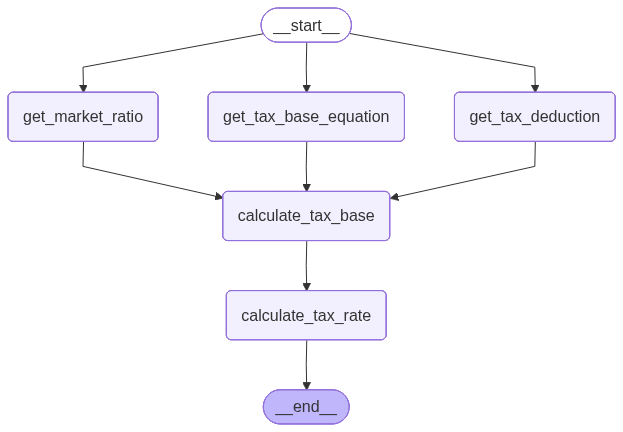

In [29]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
initial_state = {'query': query}
graph.invoke(initial_state)

context = {'query': '오늘 날짜:(2026-04-16)의 주택에 대한 종합부동산세 계산시 공정시장가액비율은 몇 %인가요?', 'response_time': 5.75, 'follow_up_questions': None, 'answer': "As of 2026, the fair market value rate for housing in South Korea's property tax is 60%. This rate is used to determine the taxable value of residential properties. This rate is subject to change based on government policy.", 'images': ['https://mblogthumb-phinf.pstatic.net/MjAyNTAzMDZfMjU1/MDAxNzQxMjA5NzE0MTI3.yjvDGrS5xiH4fyDyePIh2e2b3MPgLCUEHcVtXXnSJ7cg.75H1A46b_weyUYG1zwwo30qQid4SRPppJJMwTsZ5ObIg.PNG/image.png?type=w800', 'https://thumbnews.nateimg.co.kr/view610///news.nateimg.co.kr/orgImg/ni/2026/02/02/2602021439229090_w.jpg', 'https://mblogthumb-phinf.pstatic.net/MjAyNTAzMDZfMzMg/MDAxNzQxMjA5NjU1NDcy.-9-c3YhVkE1_LQSZuoTeOlWwtBJaJZ7Zr8QOkpiVTbUg.wpdkmuG8YVq9og_7SSmGzmguM_R6IkDR2Eb-WZrc98gg.PNG/image.png?type=w800', 'https://img3.daumcdn.net/thumb/R658x0.q70/?fname=https://t1.daumcdn.net/news/202604/12/chosunbiz/20260412060228453aqkr.jpg', 'ht

{'query': '일반인이 5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내야 하나요?',
 'answer': '주어진 정보로 계산하면, 사용자는 **3주택 보유자**이므로 **“3주택 이상” 세율**을 적용합니다.\n\n- **과세표준:** 15억 6천만 원\n- **주택 수:** 3주택\n- 적용 구간: **12억 원 초과 25억 원 이하**\n- 해당 세율: **960만 원 + (12억 원 초과금액의 1천분의 20)**\n\n계산:\n- 15.6억 - 12억 = **3.6억 원**\n- 3.6억 × 0.02 = **720만 원**\n- 960만 원 + 720만 원 = **1,680만 원**\n\n## 최종 결과\n- **종합부동산세: 1,680만 원**\n\n필요하시면 제가 이 금액을 바탕으로 **농어촌특별세까지 포함한 총 납부세액**도 계산해드릴게요.',
 'tax_base_equation': '과세표준 = max[0, (공시가격 합계 - 기본공제액)] × 공정시장가액비율',
 'tax_deduction': '주택에 대한 종합부동산세 계산 시 공제금액은 **1세대 1주택자 12억 원**, **일반 개인 9억 원**, **법인 또는 법인으로 보는 단체 6억 원**입니다.  \n즉, 주택 공시가격 합산액에서 해당 공제금액을 먼저 빼고 과세표준을 계산합니다.',
 'market_ratio': '2026-04-16 기준, **주택에 대한 종합부동산세 공정시장가액비율은 60%**입니다.',
 'tax_base': '주어진 정보로는 **정확한 “세액”은 계산할 수 없고**, 요청하신 공식에 따라 **과세표준**까지 계산할 수 있습니다.  \n(세액 계산에는 종부세 **세율** 정보가 추가로 필요합니다.)\n\n### 1) 공시가격 합계\n- 5억 + 10억 + 20억 = **35억 원**\n\n### 2) 공제금액 적용\n사용자는 **일반 개인**이므로 공제금액은 **9억 원**\n\n- 35억 - 9억 = **26